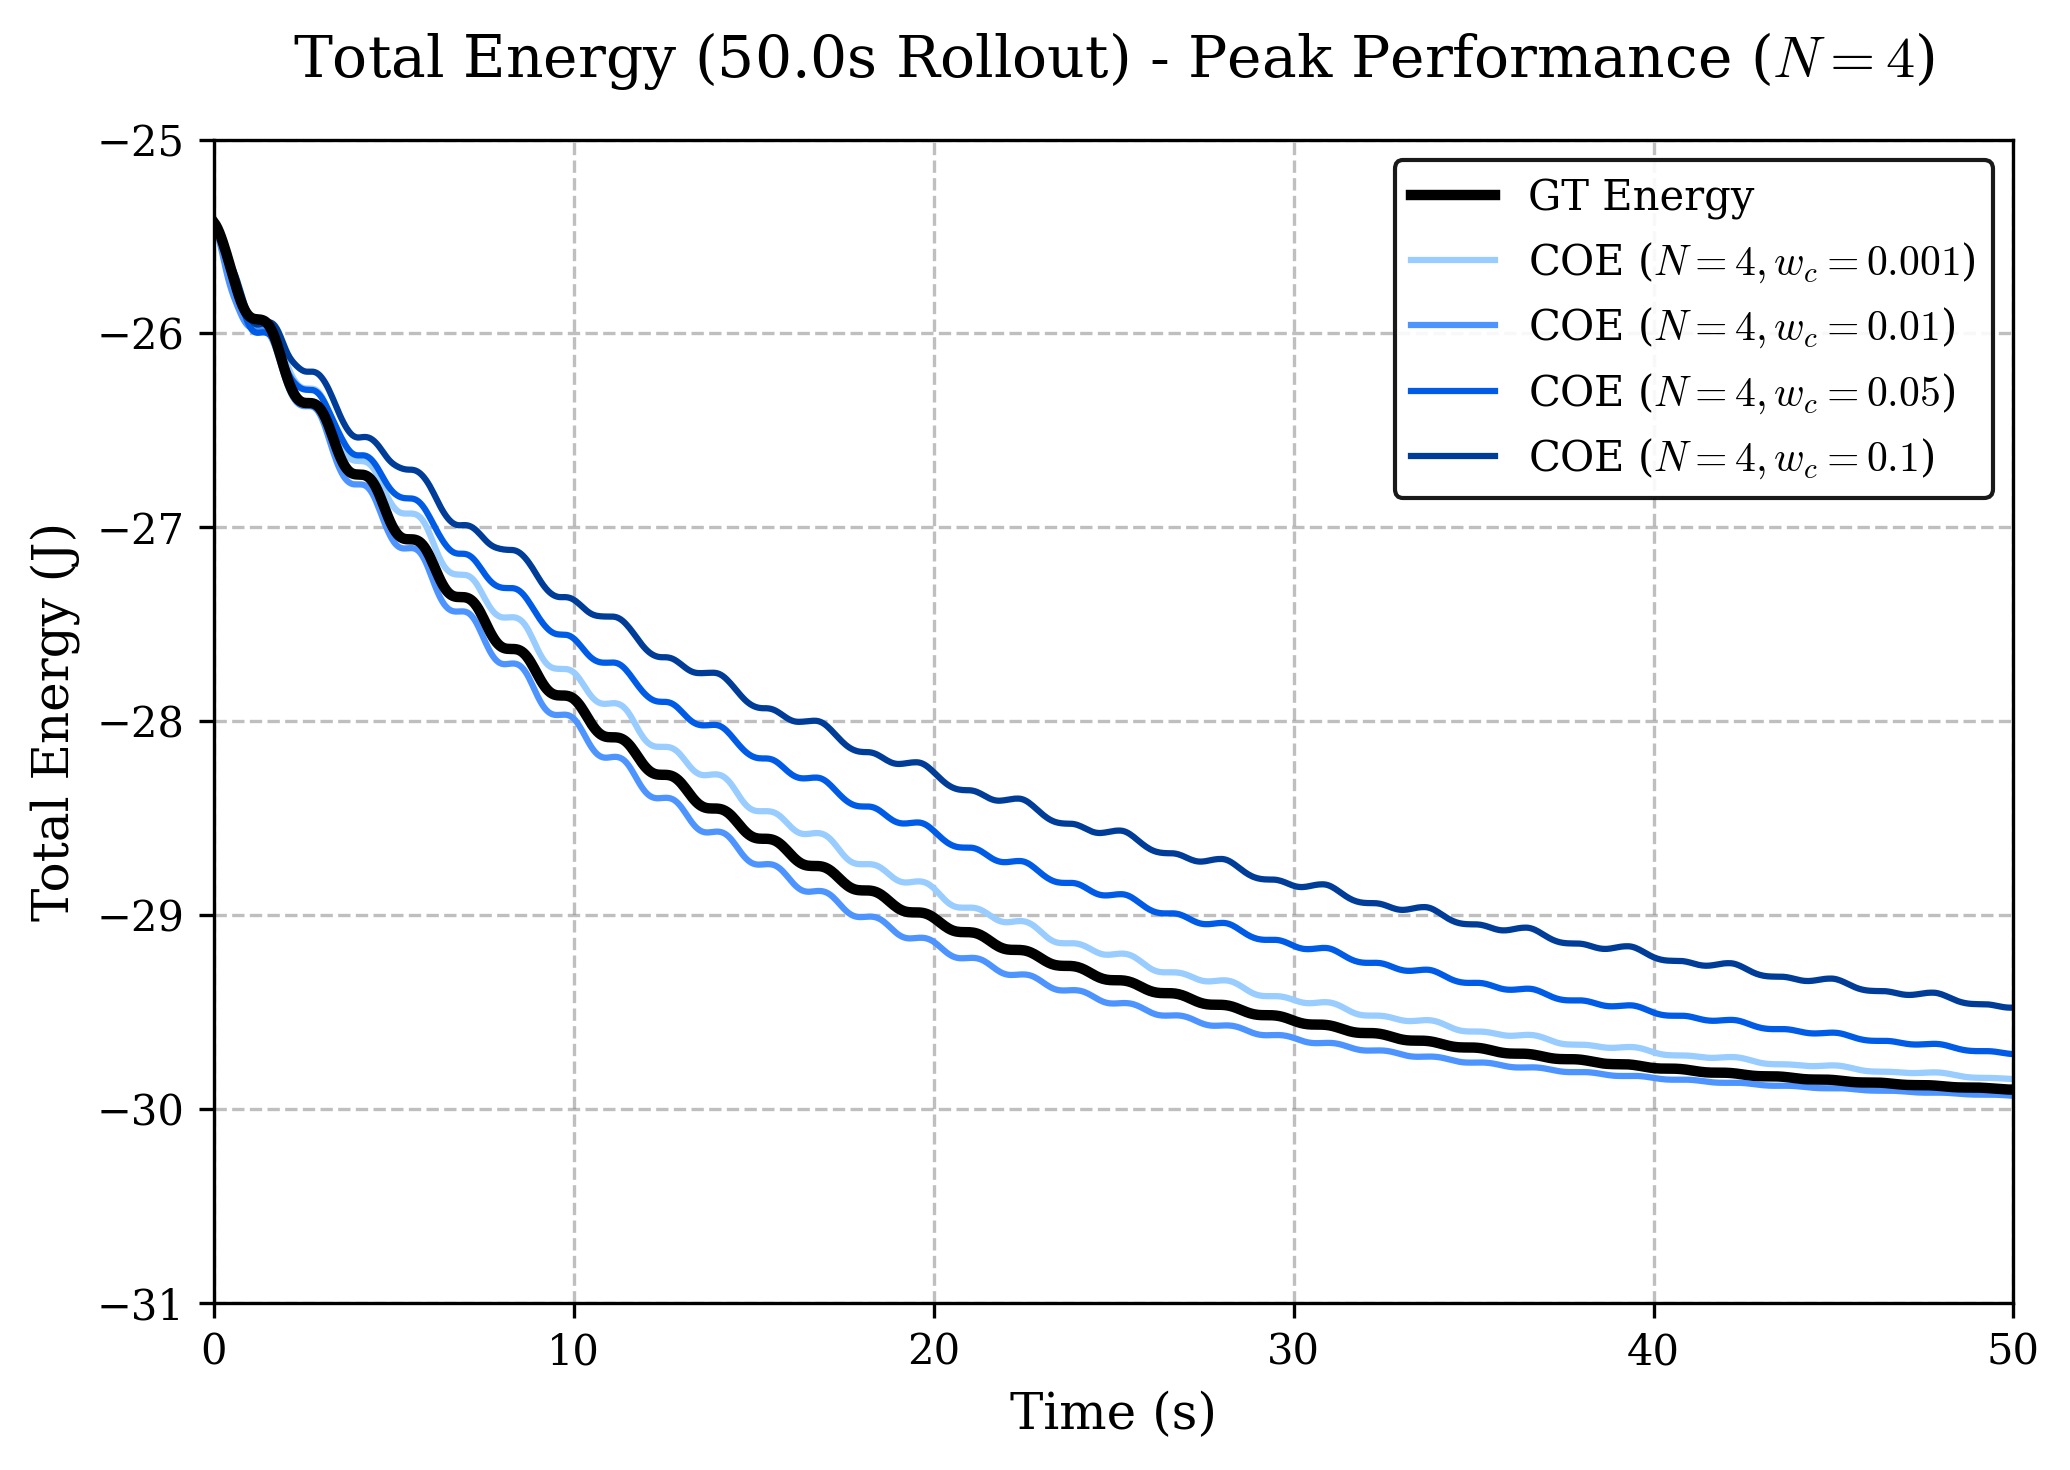

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =============================================================================
# ENVIRONMENT-SAFE PUBLICATION FORMATTING
# Uses built-in Computer Modern to avoid "latex not found" errors
# =============================================================================
mpl.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'serif'],
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# =============================================================================
# 1. LOAD RAW DATA FROM .NPY FILES
# =============================================================================
# Assuming you are plotting the N=4 champion models.
# Change the '4' to a '3' or '6' if you want to plot those ensembles instead!
data_001 = np.load("long_energy_ts_4_wc=0.001.npy", allow_pickle=True).item()
data_01  = np.load("long_energy_ts_4_wc=0.01.npy", allow_pickle=True).item()
data_05  = np.load("long_energy_ts_4_wc=0.05.npy", allow_pickle=True).item()
data_1   = np.load("long_energy_ts_4_wc=0.1.npy", allow_pickle=True).item()

# Extract time axis and Ground Truth (all files should have the same GT and time)
time = data_01['time']
GT_energy = data_01['energy_gt']

# Extract model predictions
E_wc_001 = data_001['energy_pred']
E_wc_01  = data_01['energy_pred']
E_wc_05  = data_05['energy_pred']
E_wc_1   = data_1['energy_pred']

# =============================================================================
# 2. PLOT GENERATION
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# Plot Ground Truth (Thick Black Line)
ax.plot(time, GT_energy, color='black', linewidth=2.5, label='GT Energy', zorder=5)

# Plot COE Variations (Sequential colormap: Light blue to dark blue for N=4)
colors = ['#99CCFF', '#4D94FF', '#005CE6', '#003D99']

ax.plot(time, E_wc_001, color=colors[0], linewidth=1.5, label=r'COE ($N=4, w_c=0.001$)')
ax.plot(time, E_wc_01,  color=colors[1], linewidth=1.5, label=r'COE ($N=4, w_c=0.01$)')
ax.plot(time, E_wc_05,  color=colors[2], linewidth=1.5, label=r'COE ($N=4, w_c=0.05$)')
ax.plot(time, E_wc_1,   color=colors[3], linewidth=1.5, label=r'COE ($N=4, w_c=0.1$)')

# Formatting
ax.set_title(r'Total Energy (50.0s Rollout) - Peak Performance ($N=4$)', fontsize=14, pad=15)
ax.set_xlabel(r'Time (s)')
ax.set_ylabel(r'Total Energy (J)')
ax.set_xlim([0, 50])
ax.set_ylim([-31, -25])

# Grid and Legend
ax.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.legend(loc='upper right', framealpha=0.9, edgecolor='black')

# Save Figure
plt.tight_layout()
plt.savefig('ts4_energy_superposition.png', bbox_inches='tight')
plt.savefig('ts4_energy_superposition.pdf', bbox_inches='tight')
plt.show()

✓ Successfully generated ts3_energy_superposition.png and ts3_energy_superposition.pdf


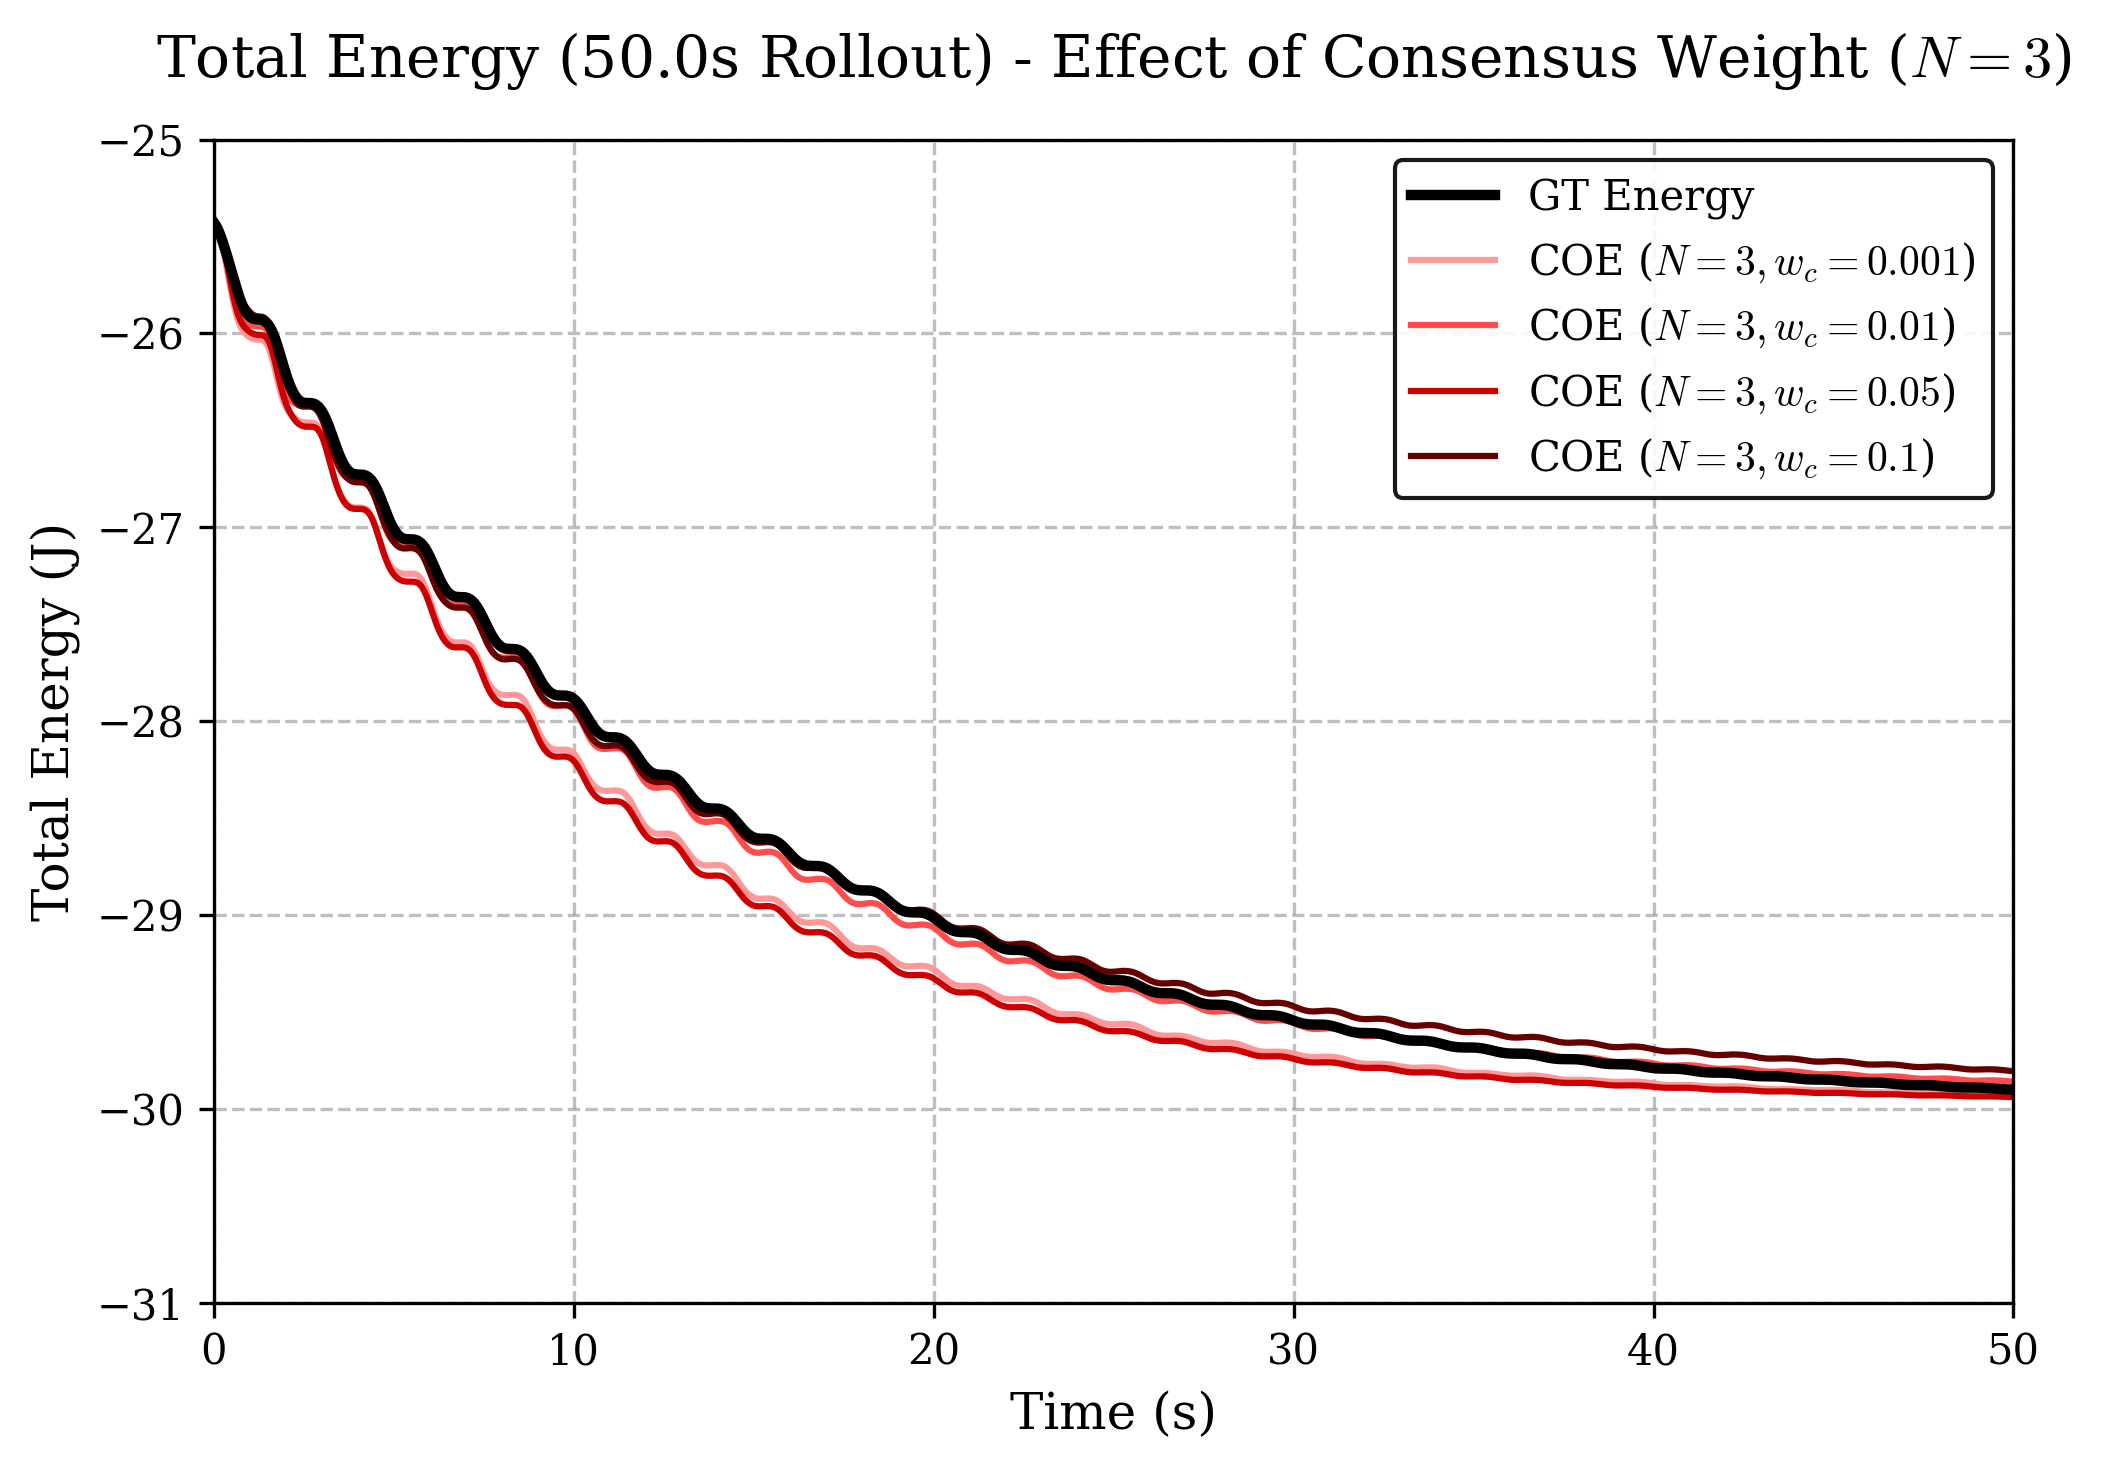

✓ Successfully generated ts6_energy_superposition.png and ts6_energy_superposition.pdf


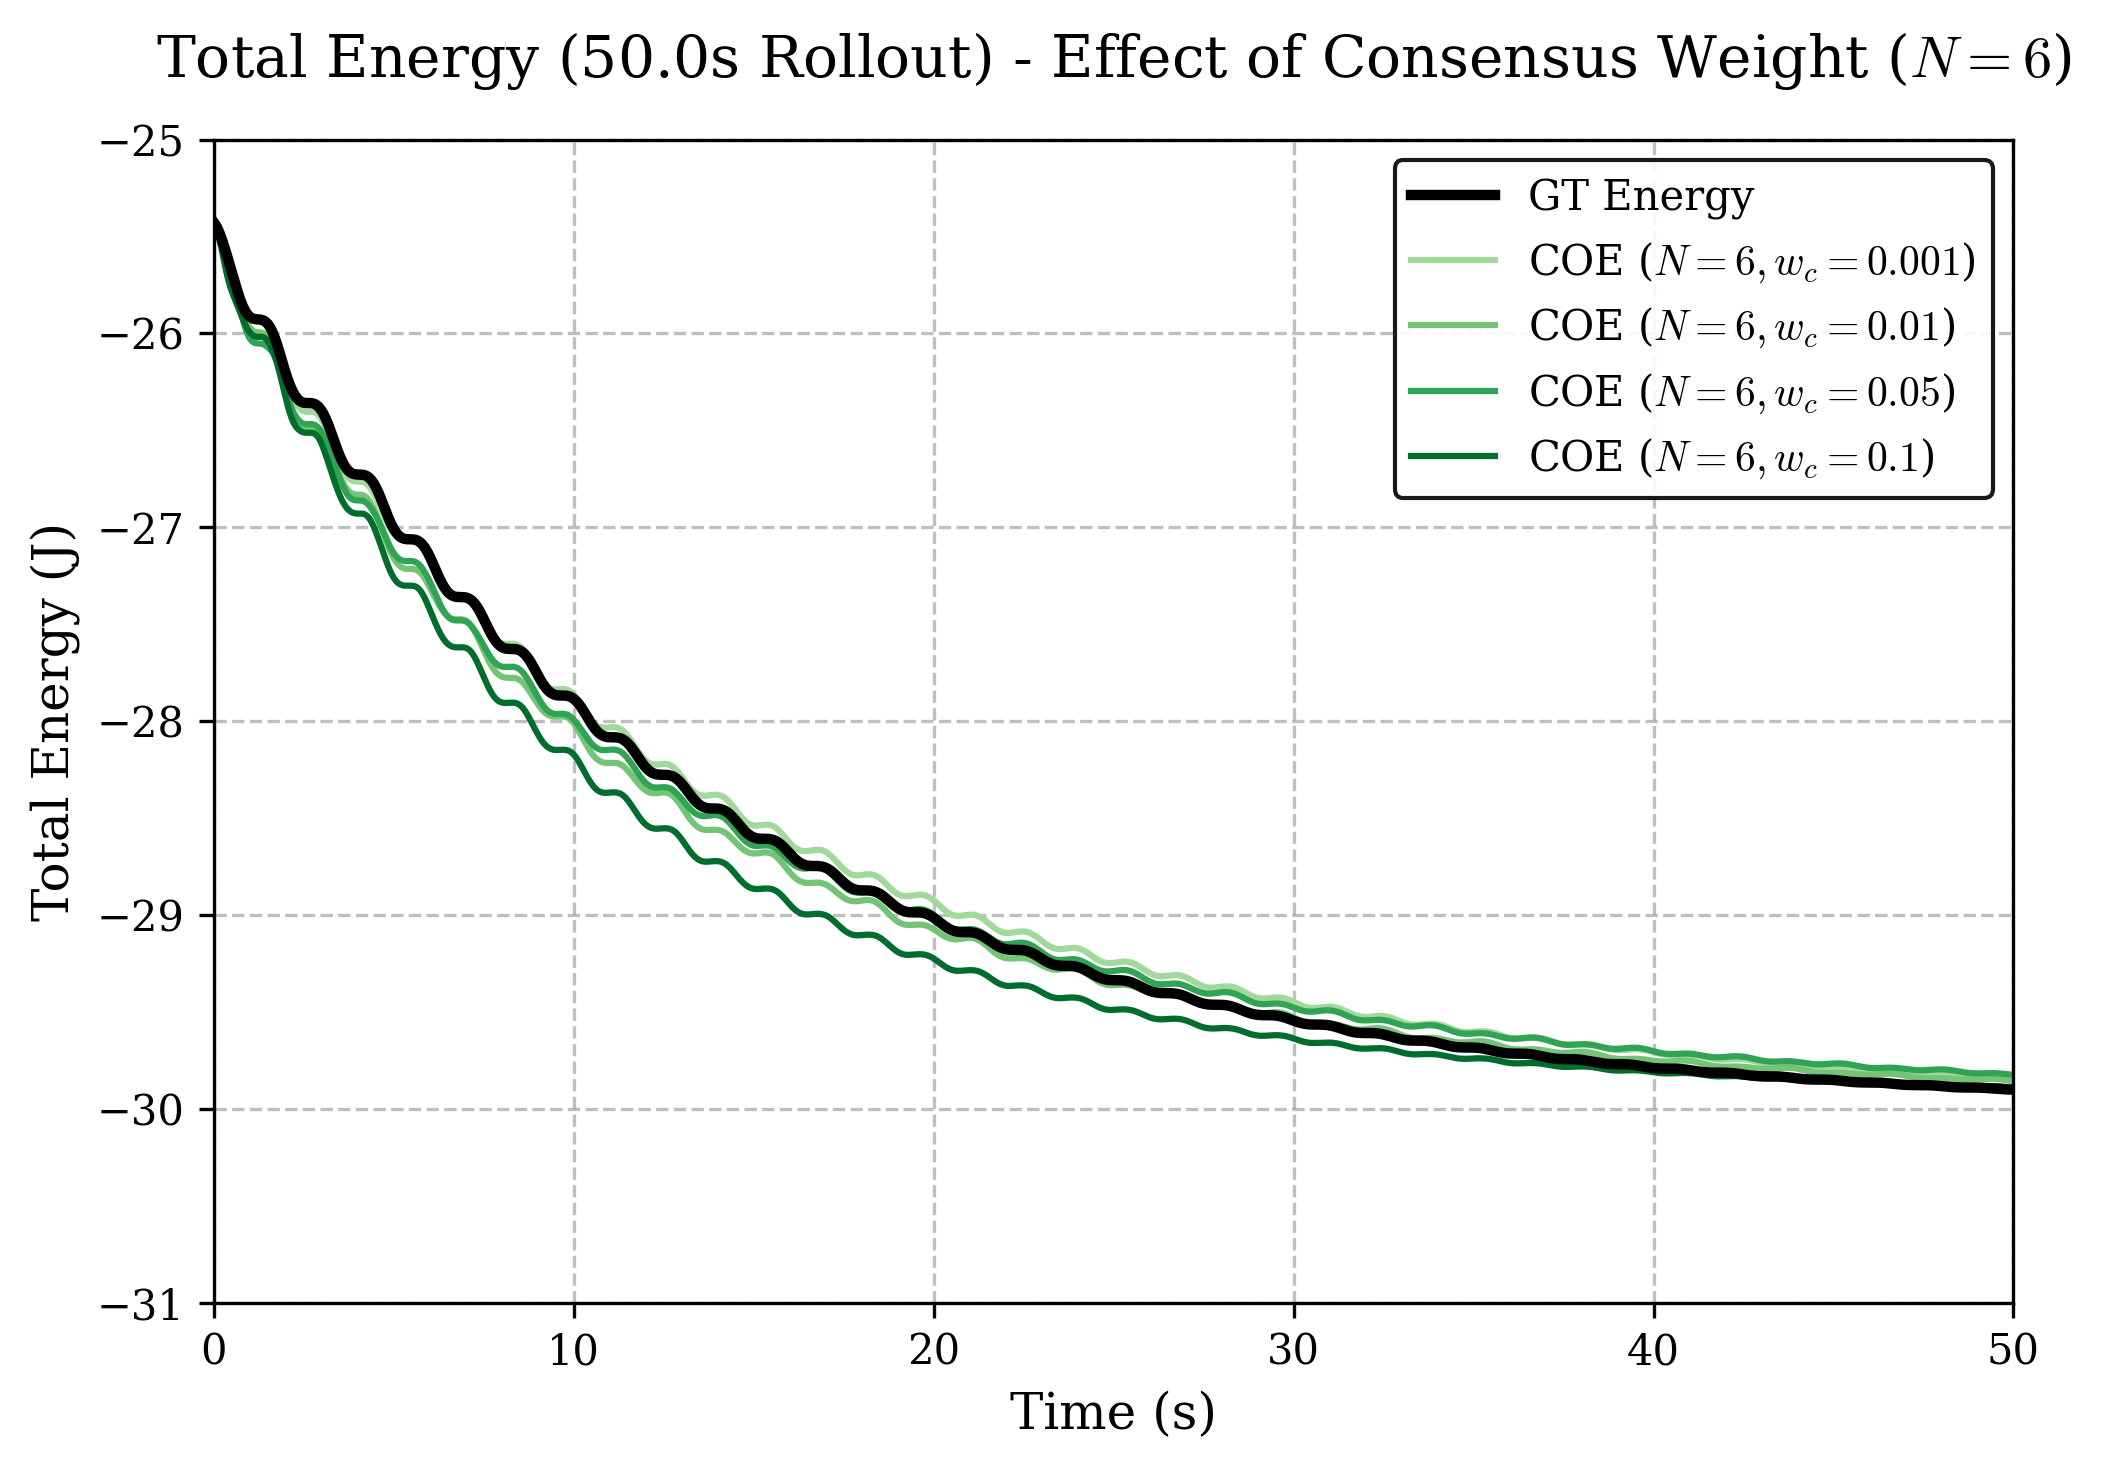

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# =============================================================================
# ENVIRONMENT-SAFE PUBLICATION FORMATTING
# Uses built-in Computer Modern to avoid "latex not found" errors
# =============================================================================
mpl.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'serif'],
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# =============================================================================
# 1. CONFIGURATION FOR ENSEMBLES
# =============================================================================
# Define unique color palettes and titles for the different ensemble sizes
ensembles = {
    3: {
        'colors': ['#FF9999', '#FF4D4D', '#CC0000', '#660000'], # Light to Dark Red
        'title': r'Total Energy (50.0s Rollout) - Effect of Consensus Weight ($N=3$)'
    },
    6: {
        'colors': ['#A1D99B', '#74C476', '#31A354', '#006D2C'], # Light to Dark Green
        'title': r'Total Energy (50.0s Rollout) - Effect of Consensus Weight ($N=6$)'
    }
}

w_c_values = ['0.001', '0.01', '0.05', '0.1']

# =============================================================================
# 2. AUTOMATED PLOT GENERATION
# =============================================================================
for N, config in ensembles.items():
    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

    # Identify the base file to extract the time axis and Ground Truth
    base_file = f"long_energy_ts_{N}_wc=0.01.npy"

    if not os.path.exists(base_file):
        print(f"--- Skipping N={N}: Base file '{base_file}' not found in directory. ---")
        continue

    # Load base data
    data_base = np.load(base_file, allow_pickle=True).item()
    time = data_base['time']
    GT_energy = data_base['energy_gt']

    # Plot Ground Truth (Thick Black Line)
    ax.plot(time, GT_energy, color='black', linewidth=2.5, label='GT Energy', zorder=5)

    # Plot each wc variation from the actual .npy files
    for i, wc in enumerate(w_c_values):
        file_name = f"long_energy_ts_{N}_wc={wc}.npy"

        if os.path.exists(file_name):
            data = np.load(file_name, allow_pickle=True).item()
            E_pred = data['energy_pred']
            ax.plot(time, E_pred, color=config['colors'][i], linewidth=1.5,
                    label=rf'COE ($N={N}, w_c={wc}$)')
        else:
            print(f"Notice: Missing file '{file_name}', skipping this line.")

    # Formatting
    ax.set_title(config['title'], fontsize=14, pad=15)
    ax.set_xlabel(r'Time (s)')
    ax.set_ylabel(r'Total Energy (J)')
    ax.set_xlim([0, 50])
    ax.set_ylim([-31, -25])

    # Grid and Legend
    ax.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.legend(loc='upper right', framealpha=0.9, edgecolor='black')

    # Save Figure
    plt.tight_layout()
    png_name = f'ts{N}_energy_superposition.png'
    pdf_name = f'ts{N}_energy_superposition.pdf'
    plt.savefig(png_name, bbox_inches='tight')
    plt.savefig(pdf_name, bbox_inches='tight')

    print(f"✓ Successfully generated {png_name} and {pdf_name}")
    plt.show()